In [70]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# Each Path Specification

In [71]:
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier.keras'

# Number of categories setting

In [72]:
NUM_CLASSES = 31

# Load learning data

In [73]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [74]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# Model Construction

In [76]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [77]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_6 (Dropout)             │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 20)             │           860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 31)             │           341 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,411 (5.51 KB)

 Trainable params: 1,411 (5.51 KB)

 Non-trainable params: 0 (0.00 B)

In [78]:
# Callback for saving model checkpoints
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# Callback for early stopping during training
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [79]:
# Model compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model Training

In [80]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000


237/273 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0411 - loss: 3.4230
Epoch 1: saving model to model/keypoint_classifier/keypoint_classifier.keras

Epoch 1: finished saving model to model/keypoint_classifier/keypoint_classifier.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0558 - loss: 3.3611 - val_accuracy: 0.1040 - val_loss: 3.2087
Epoch 2/1000
254/273 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0960 - loss: 3.1707
Epoch 2: saving model to model/keypoint_classifier/keypoint_classifier.keras

Epoch 2: finished saving model to model/keypoint_classifier/keypoint_classifier.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1238 - loss: 3.0522 - val_accuracy: 0.2741 - val_loss: 2.5968
Epoch 3/1000
241/273 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1872 - loss: 2.6686
Epoch 3: saving model to model/keypoint_classifier/keypoint_classifier.keras

Epoch 3: finished saving model to model/keypoint_classifier/keypoint_classifier.keras
273/273 ━━━━━━━━━━━━━━━

In [81]:
# Model evaluation
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8199 - loss: 0.7266 


In [82]:
# Load the saved model
model = tf.keras.models.load_model(model_save_path)

In [83]:
# Inference test
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
[1.1832011e-08 7.2338122e-09 1.6680458e-07 1.4551750e-10 3.9702761e-03
 3.6322788e-04 1.1591926e-02 6.5212943e-02 3.0504295e-03 6.5558381e-02
 2.4771263e-04 5.6799371e-07 4.8853920e-08 6.9340635e-03 2.9796914e-03
 2.0813791e-03 1.6394306e-04 2.7199160e-10 1.2833897e-09 2.5973964e-01
 4.8991266e-01 6.1644467e-10 1.7081449e-07 9.7403385e-10 1.5778647e-09
 8.8058144e-02 1.6792560e-06 1.6934244e-10 1.3292044e-04 2.1665240e-08
 5.0826953e-13]
20


# Confusion Matrix

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 843us/step


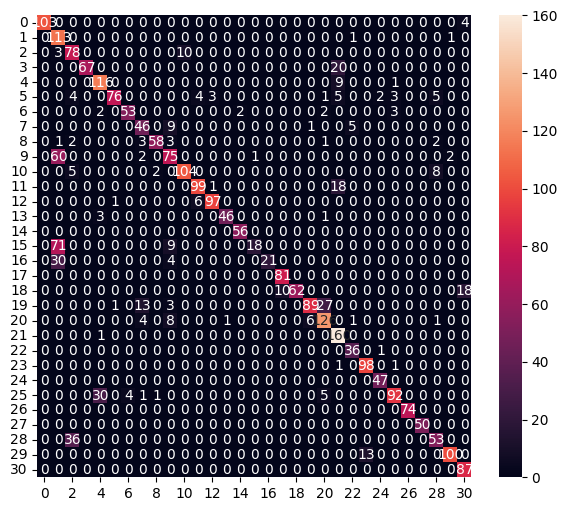

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       107
           1       0.41      0.98      0.58       115
           2       0.62      0.86      0.72        91
           3       1.00      0.77      0.87        87
           4       0.76      0.92      0.83       126
           5       0.97      0.74      0.84       103
           6       0.93      0.85      0.89        62
           7       0.67      0.75      0.71        61
           8       0.95      0.83      0.89        70
           9       0.68      0.54      0.60       140
          10       0.91      0.87      0.89       119
          11       0.91      0.84      0.87       118
          12       0.96      0.93      0.95       104
          13       0.98      0.92      0.95        50
          14       0.97      1.00      0.98        56
          15       0.95      0.18      0.31        98
          16       1.00      0.38      0.55        55
     

In [84]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Convert to a TensorFlow Lite model

In [85]:
# Save as an inference-only model
model.save(model_save_path, include_optimizer=False)

In [86]:
print(type(model))
print(model)

<class 'keras.src.models.sequential.Sequential'>
<Sequential name=sequential_3, built=True>


In [87]:
import tensorflow as tf

tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

# تحميل الموديل
keras_model = tf.keras.models.load_model(
    'model/keypoint_classifier/keypoint_classifier.keras'
)

# إنشاء concrete function
@tf.function(input_signature=[tf.TensorSpec(shape=[None, 42], dtype=tf.float32)])
def model_fn(x):
    return keras_model(x)

concrete_func = model_fn.get_concrete_function()

# التحويل إلى TFLite
converter = tf.lite.TFLiteConverter.from_concrete_functions([concrete_func], keras_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

# الحفظ
with open(tflite_save_path, 'wb') as f:
    f.write(tflite_model)

print("تم حفظ tflite بنجاح")

تم حفظ tflite بنجاح


# Inference Test

In [88]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

In [89]:
# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [90]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [91]:
%%time
# Run inference
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: total: 0 ns
Wall time: 0 ns


In [92]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[1.1831994e-08 7.2337878e-09 1.6680465e-07 1.4551811e-10 3.9702756e-03
 3.6322820e-04 1.1591931e-02 6.5212913e-02 3.0504353e-03 6.5558329e-02
 2.4771263e-04 5.6799342e-07 4.8853849e-08 6.9340570e-03 2.9796872e-03
 2.0813742e-03 1.6394281e-04 2.7199118e-10 1.2833903e-09 2.5973952e-01
 4.8991290e-01 6.1644373e-10 1.7081425e-07 9.7403230e-10 1.5778623e-09
 8.8058166e-02 1.6792520e-06 1.6934187e-10 1.3292037e-04 2.1665251e-08
 5.0826877e-13]
20
